In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [7]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=10000,n_features=3,n_redundant=1,n_classes=2)
X,y

(array([[-0.07323351,  1.8591195 ,  1.29103979],
        [-0.15507586,  1.25386327,  0.03894843],
        [-0.02713107, -1.08457751, -1.30295156],
        ...,
        [ 0.04231746,  0.43157151,  0.76655397],
        [-0.27103879,  0.51586483, -1.61502085],
        [-0.01260228, -0.08148224, -0.18103116]], shape=(10000, 3)),
 array([1, 1, 0, ..., 1, 0, 0], shape=(10000,)))

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
X_train[:,0].shape,y_train.shape

((7500,), (7500,))

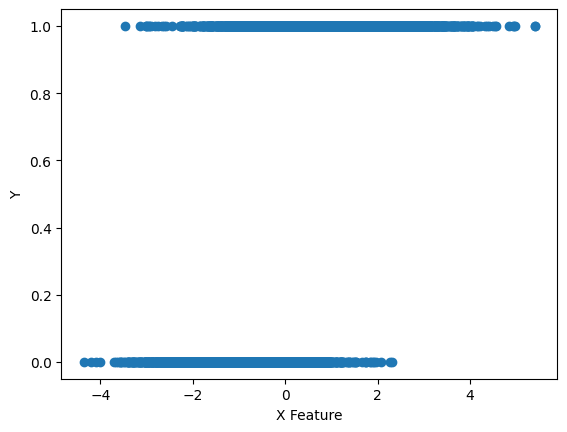

In [9]:
plt.scatter(X_train[:,2],y_train)
plt.xlabel("X Feature")
plt.ylabel("Y")
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8212
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1259
           1       0.83      0.80      0.82      1241

    accuracy                           0.82      2500
   macro avg       0.82      0.82      0.82      2500
weighted avg       0.82      0.82      0.82      2500



In [14]:
param_grid = {
    "solver":["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
    "penalty":["l1","l2","elasticnet","None"],
    "C":[0.01,0.1,1.0,10,1000]
}

In [15]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=logistic,param_grid=param_grid)

In [16]:
grid.fit(X_train,y_train)
y_pred = grid.predict(X_test)

In [17]:
grid.best_params_

{'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}

In [18]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.822
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1259
           1       0.83      0.80      0.82      1241

    accuracy                           0.82      2500
   macro avg       0.82      0.82      0.82      2500
weighted avg       0.82      0.82      0.82      2500

